semantic segmentation is like image classification but we are assigning a label to every pixel in the image
image classification --> assigns a label to the entire image
object detectoin --> identifies the objects using a bbox (improvement over image classifica tion)
instance segmnetatoin --> object detection + semantic segmentation tgt

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

--> normalization - subtract mean and divide by std
subtracting mean -> adjusting for brightness
dividing std -> adjusting for contrast

use torchvision
--> input is N x C x H x W
- C is classes, so the number of objects u want to identify are the number of classes
- torchvision models outputs and OrderedDict, not a torch.Tensor

# load basic segmentation models 
--> one of the earliest 
--> performanced is okay only

In [1]:
from PIL import Image
from torchvision import models

import torchvision
import os
import subprocess
import matplotlib.pyplot as plt
import torch
import requests
import time

plt.style.use('ggplot')

In [ ]:
# one of the earliest models deployed for semantic segmentation

# load segmentation model

fcn = torchvision.models.segmentation.fcn_resnet101(
    weights=torchvision.models.segmentation.FCN_ResNet101_Weights.DEFAULT
).eval()

In [46]:
img = Image.open('data/cat-and-dog1.jpeg')
print(img.size)

(1200, 1200)


In [47]:
import matplotlib.pyplot as plt

def plot_tensor_image(img: torch.Tensor):
    img = img.detach().cpu().permute(1,2,0)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [48]:
import torchvision.transforms as T

transforms = T.Compose([
    # T.Resize(256),
    T.Resize((224, 224)),
    # T.CenterCrop(224),
    T.ToTensor(), # this normalizes to 0-1 --> can check docs
    T.Normalize(
        mean=[0.485, 0.456, 0.406], # these are imagenet values
        std=[0.229, 0.224, 0.225]
    )
])

timg = transforms(img)

In [74]:
# img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


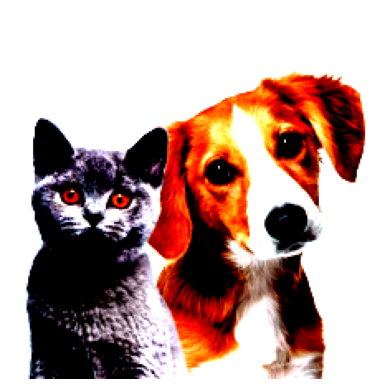

In [50]:
plot_tensor_image(timg)

In [51]:
print(timg.shape)
timg = timg.unsqueeze(0) # make it compatible with the network
print(timg.shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [52]:
out = fcn(timg)['out']
print(out.shape)

torch.Size([1, 21, 224, 224])


In [57]:
out[0,0,:5,:5]

tensor([[9.9020, 9.9020, 9.9020, 9.9020, 9.8865],
        [9.9020, 9.9020, 9.9020, 9.9020, 9.8865],
        [9.9020, 9.9020, 9.9020, 9.9020, 9.8865],
        [9.9020, 9.9020, 9.9020, 9.9020, 9.8865],
        [9.8881, 9.8881, 9.8881, 9.8881, 9.8738]], grad_fn=<SliceBackward0>)

21 channels --> one for each class the model was trained on

In [58]:
# need to get the torch.argmax for each pixel in the image across all N channels

maxOut = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
maxOut

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(224, 224))

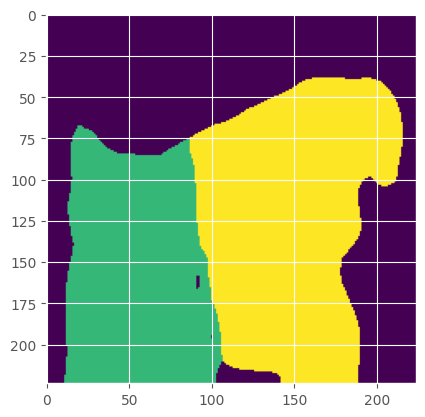

In [59]:
plt.imshow(maxOut)

In [60]:
import numpy as np
np.unique(maxOut)

array([ 0,  8, 12])

In [ ]:
# this function will change according to the number of classes the model was trained on

def decode_segmap(image, num_channels=21):
    # Define Pascal VOC color palette (21 colors)
    label_colors = np.array([
        [0, 0, 0],        # background
        [128, 0, 0],      # aeroplane
        [0, 128, 0],      # bicycle
        [128, 128, 0],    # bird
        [0, 0, 128],      # boat
        [128, 0, 128],    # bottle
        [0, 128, 128],    # bus
        [128, 128, 128],  # car
        [64, 0, 0],       # cat
        [192, 0, 0],      # chair
        [64, 128, 0],     # cow
        [192, 128, 0],    # dining table
        [64, 0, 128],     # dog
        [192, 0, 128],    # horse
        [64, 128, 128],   # motorbike
        [192, 128, 128],  # person
        [0, 64, 0],       # potted plant
        [128, 64, 0],     # sheep
        [0, 192, 0],      # sofa
        [128, 192, 0],    # train
        [0, 64, 128],     # tv/monitor
    ], dtype=np.uint8)

    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)

    for l in range(num_channels):
        idx = image == l # returns bool array
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]
    
    rgb = np.stack([r,g,b], axis=2)
    return rgb

In [64]:
rgb = decode_segmap(maxOut)
rgb.shape

(224, 224, 3)

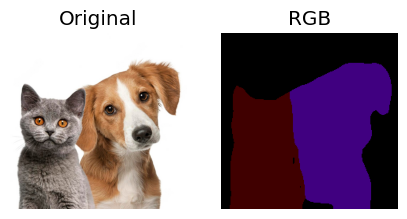

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(5,10))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(rgb)
ax[1].set_title("RGB")
ax[1].axis('off')

plt.show()

In [83]:
from PIL import Image
from torchvision import models

import torchvision
import os
import subprocess
import matplotlib.pyplot as plt
import torch
import requests
import time

plt.style.use('ggplot')

def load_infer_and_plot(image_path: str):
    img = Image.open(image_path)

    t_img = transforms(img)
    t_img = t_img.unsqueeze(0)

    out = fcn(t_img)['out']
    maxOut = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
    rgb = decode_segmap(maxOut)

    _, ax = plt.subplots(1, 2, figsize=(5, 2.5))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis('off')

    ax[1].imshow(rgb)
    ax[1].set_title("RGB")
    ax[1].axis('off')

    plt.show()

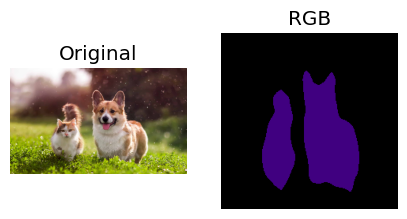

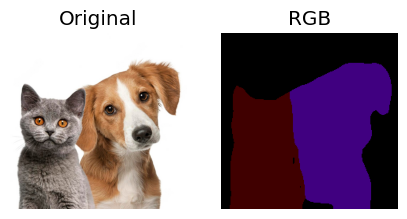

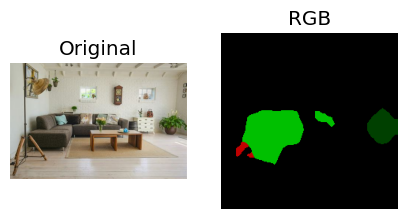

In [84]:
import glob

for path in glob.glob(f'data/*.jpg') + glob.glob(f'data/*.jpeg'):
    load_infer_and_plot(path)

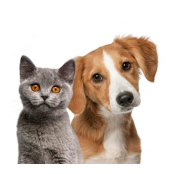

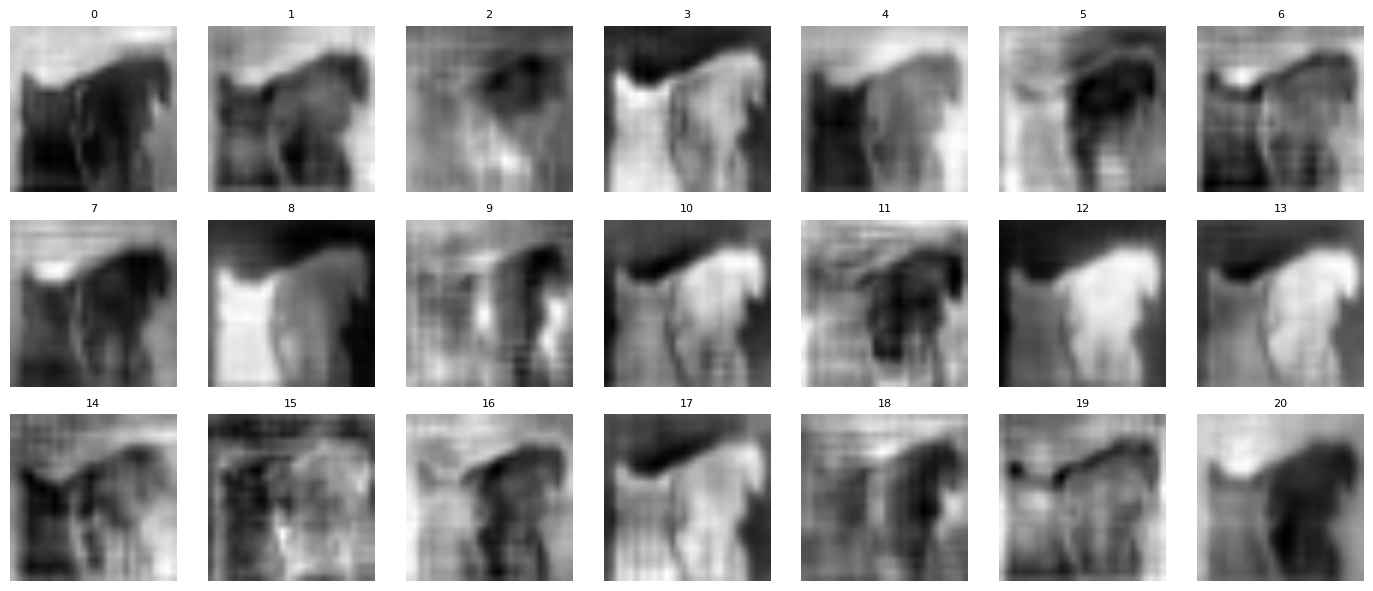

In [92]:
# check the predictions to understand better
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))
plt.imshow(img)
plt.axis('off')
plt.show()

# Assuming out has shape [batch, channels, height, width]
maps = out[0].detach().cpu()  # take the first image in batch

num_maps = 21
cols = 7  # number of columns in the grid
rows = (num_maps + cols - 1) // cols  # auto-calc rows

plt.figure(figsize=(14, 6))
for i in range(num_maps):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(maps[i], cmap='gray')
    plt.title(f'{i}', fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


# use a stronger segmentation model

In [93]:
dlab = models.segmentation.deeplabv3_resnet101(
    weights="COCO_WITH_VOC_LABELS_V1"
).eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /Users/I748920/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:04<00:00, 50.3MB/s] 


In [94]:
type(fcn)

torchvision.models.segmentation.fcn.FCN

In [104]:
from PIL import Image
from torchvision import models

import torchvision
import os
import subprocess
import matplotlib.pyplot as plt
import torch
import requests
import time

plt.style.use('ggplot')

def load_infer_and_plot(image_path: str, model: torchvision.models.segmentation):
    img = Image.open(image_path)

    t_img = transforms(img)
    t_img = t_img.unsqueeze(0)

    out = model(t_img)['out']
    maxOut = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
    rgb = decode_segmap(maxOut)

    _, ax = plt.subplots(1, 2, figsize=(5, 2.5))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis('off')

    ax[1].imshow(rgb)
    ax[1].set_title("RGB")
    ax[1].axis('off')

    plt.show()

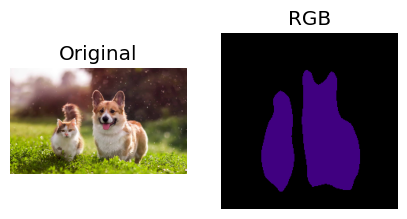

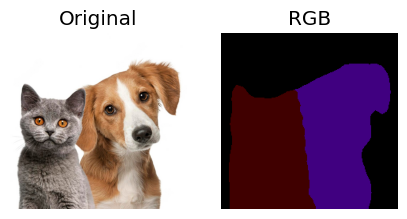

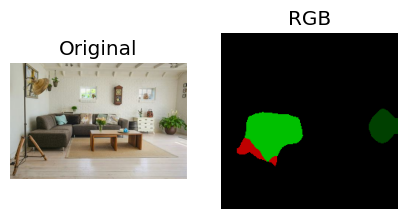

In [105]:
import glob

for path in glob.glob(f'data/*.jpg') + glob.glob(f'data/*.jpeg'):
    load_infer_and_plot(path, model=dlab)

| Model                   | Architecture                                                 | Key Mechanism                                                                                                               |
| ----------------------- | ------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------- |
| **FCN-ResNet101**       | *Fully Convolutional Network (FCN)*                          | Uses simple upsampling (bilinear interpolation) after the backbone. Predicts per-pixel classes from the final feature maps. |
| **DeepLabV3-ResNet101** | *Atrous Convolution + ASPP (Atrous Spatial Pyramid Pooling)* | Captures multi-scale context using dilated convolutions. Much better at handling objects of varying sizes.                  |


🧠 In short:

FCN: simpler, direct pixel-wise prediction

DeepLabV3: more sophisticated, captures context + scale variations

| Task                     | Output Type            | What It Predicts                       | Example Output                        |
| ------------------------ | ---------------------- | -------------------------------------- | ------------------------------------- |
| **Image Classification** | Single label per image | One class representing the whole image | 🏷️ “Dog”                             |
| **Image Segmentation**   | Label per pixel        | A class for every pixel in the image   | 🎨 Each pixel = “dog”, “grass”, “sky” |


https://medium.com/data-reply-it-datatech/an-introduction-to-semantic-segmentation-4a01f68cf2a3